# 01 - plot_plume_path_sum\n
Derived from `notebooks/prior_versions/plume_path_plot_clean.ipynb`.\n

In [35]:
import platform
import socket
import sys
from pathlib import Path

src_dir = next(p / "src" for p in (Path.cwd(), *Path.cwd().parents) if (p / "src" / "polarcap_runtime.py").is_file())
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from polarcap_runtime import is_server

print("system:", platform.system(), platform.release())
print("hostname:", socket.gethostname())
print("is_server:", is_server())

system: Darwin 25.3.0
hostname: MacBookPro
is_server: False


In [36]:
from __future__ import annotations

import sys
from pathlib import Path
import numpy as np
import xarray as xr

xr.set_options(keep_attrs=True)
_src = next((p / "src" for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utilities").is_dir()), (Path.cwd() / ".." / ".." / "src").resolve())
sys.path.insert(0, str(_src))

from utilities import (
    make_pastel,
    create_fade_cmap,
    load_plume_path_runs,
    plot_plume_path_sum,
    build_common_xlim,
    diagnostics_table,
    prepare_holimo_for_overlay,
)
from utilities.plotting import create_new_jet3

# Colormaps for plume-path (ice + transition + BkBl; soft for overlay)
new_jet4 = create_new_jet3(1024)
new_jet3 = create_new_jet3()
new_jet3_soft = create_fade_cmap(make_pastel(new_jet3, desaturation=0.25, darken=0.90), n_fade=2)


In [37]:
# ---- user config ----\n
PROCESSED_ROOT = Path("../../data/processed")
RUNS = [
    # {"label": "400m, inp 1e6, ccn 0 (run A)", "cs_run": "cs-eriswil__20251129_230943", "exp_id": "20251129231107"},
    # {"label": "400m, inp 1e6, ccn 0 (run B)", "cs_run": "cs-eriswil__20251129_230943", "exp_id": "20260119103733"},
    # {"label": "400m, inp 1e6, ccn 400 (columnar)", "cs_run": "cs-eriswil__20251125_114053", "exp_id": "20260120122711"},
    # {"label": "400m, inp 1e6, ccn 0 (spherical)", "cs_run": "cs-eriswil__20251125_114053", "exp_id": "20251125114238"},
    # {"label": "400m, inp 1e6, ccn 400 (analytic)", "cs_run": "cs-eriswil__20260127_211338", "exp_id": "20260127211431"},
    # {"label": "400m, inp 1e6, ccn 400 (planar)", "cs_run": "cs-eriswil__20260127_211338", "exp_id": "20260127211551"},
    # {"label": "400m, inp 1e6, ccn 400 (spherical)", "cs_run": "cs-eriswil__20260121_131528", "exp_id": "20260121131550"},
    {"label": "400m, inp 1e6, ccn 400 (columnar 2)", "cs_run": "cs-eriswil__20260121_131528", "exp_id": "20260121131632"},
    # {"label": "100m, inp 1e6, ccn 0 (columnar)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181336"},
    # {"label": "100m, inp 1e6, ccn 400 (columnar)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181750"},
    # {"label": "100m, inp 1e6, ccn 400 (spherical, same exp)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181750"},
]

KINDS = ("integrated","vertical","extreme")

datasets = load_plume_path_runs(
    RUNS,
    processed_root=PROCESSED_ROOT,
    kinds=KINDS,
)

try:
    xlim = build_common_xlim(datasets, kind="integrated", span_min=35)
except ValueError:
    # Fallback window if no valid times are discoverable in current environment.
    xlim = [np.datetime64("2023-01-25T12:29:00"), np.datetime64("2023-01-25T13:04:00")]
    # xlim = [np.datetime64("2023-01-25T12:29:00"), np.datetime64("2023-01-25T13:04:00")]

diag = diagnostics_table(datasets, kind="integrated", variable="nf", xlim=xlim)
print(diag.to_string(index=False))



                                run status  n_cells  n_time            time_min            time_max  has_var  n_time_in_xlim  finite_in_xlim
400m, inp 1e6, ccn 400 (columnar 2)     ok        5     289 2023-01-25T12:23:50 2023-01-25T13:11:50     True             211           12066


In [38]:
# plot_plume_path_sum and helpers → utilities.plume_path_plot


In [39]:
# Model data and xlim from cell 3


# HOLIMO DATA


TBD: check how much smoothing of the Holimo data is needed to do a comparison with the model data. Holimos observationsal volume is in order of a couple of centimeters compared to the model which is of horizontal resolution of >400m (or >100m depending on the run).


In [40]:
holimo_file = "../../data/observations/holimo_data/CL_20230125_1000_1140_SM058_SM060_ts1.nc"
time_window_holimo = (np.datetime64("2023-01-25T10:10:00"), np.datetime64("2023-01-25T12:00:00"))
time_frames_plume = [
    [np.datetime64("2023-01-25T10:55:00"), np.datetime64("2023-01-25T11:10:00")],
    [np.datetime64("2023-01-25T10:35:00"), np.datetime64("2023-01-25T10:50:00")],
    [np.datetime64("2023-01-25T11:24:00"), np.datetime64("2023-01-25T11:39:00")],
]
obs_ids = ["SM059", "SM058", "SM060"]
growth_times_min = [6.1, 8.0, 9.1]
seeding_start_times = [
    np.datetime64("2023-01-25T10:50:00"),
    np.datetime64("2023-01-25T10:28:00"),
    np.datetime64("2023-01-25T11:15:00"),
]
ds_hd10 = prepare_holimo_for_overlay(
    holimo_file,
    time_window_holimo,
    resample_s=10,
    smoothing_time_bins=8,
    min_coverage_frac=0.01,
)


### HOLIMO time smoothing (gap-aware, paper method)

We process HOLIMO time series with a gap-aware workflow before plume comparisons:

- **Regularization:** resample to a fixed `10 s` grid (`mean`).
- **Coverage filter:** keep only `10 s` bins with at least `20%` of expected raw samples (for `0.2 s` raw data, threshold = `10` samples per `10 s` bin).
- **Smoothing:** apply a centered `30 s` rectangular window (`rolling(time=3, center=True, min_periods=2)`) on the regularized series.

This keeps the effective smoothing window consistent in time and limits bias from irregular sampling gaps.

In [41]:
# import matplotlib.pyplot as plt
# from utilities import _assign_elapsed_time, _prepare_da
# from matplotlib.lines import Line2D


# # Updated FoO block: one model line over global HOLIMO elapsed window.
# holimo_ice_var = "Ice_Pristine_PSDnoNorm"
# cs_run = list(datasets.keys())[1]
# ds = datasets[cs_run]

# holimo_overlay_cfg = {
#     "ds_hd10": ds_hd10,
#     "obs_ids": obs_ids,
#     "time_frames_plume": time_frames_plume,
#     "growth_times_min": growth_times_min,
#     "seeding_start_times": seeding_start_times,
#     "var": holimo_ice_var,
#     "threshold": 1e-10,
#     "unit_factor": 1e3,
#     "scatter_cmap": new_jet3_soft,
#     "markers": ["o", "s", "^"],
#     "sizes": [90, 90, 90],
#     "alpha": 1.0,
#     "edgecolor": "black",
#     "linewidth": 0.25,
#     "legend_loc": "lower right",
#     "marker_size_scale": 1.0,
# }

# xlims = {"symlog": [0, 35], "elapsed": [4, 15]}
# ylims = {"symlog": [1, 1000], "elapsed": [20, 250]}
# xlim_npdatetime = [np.datetime64("2023-01-25T12:29:00"), np.datetime64("2023-01-25T13:14:00")]

# # Histogram settings for comparison panel.
# HIST_DIAM_BOUNDS = (10.0, 1000.0)
# absolute_mode = True  # True: absolute time-mean concentration, False: FoO (%)
# # HIST_BIN_EDGES = np.array([HIST_DIAM_BOUNDS[0], HIST_DIAM_BOUNDS[1]], dtype=float)


# def _diameter_centers_to_log_edges(diameter_centers: np.ndarray) -> np.ndarray:
#     centers = np.asarray(diameter_centers, dtype=float)
#     centers = np.sort(centers[np.isfinite(centers) & (centers > 0)])
#     centers = np.unique(centers)
#     if centers.size < 2:
#         return np.array([], dtype=float)

#     lcent = np.log(centers)
#     ledges = np.empty(centers.size + 1, dtype=float)
#     ledges[1:-1] = 0.5 * (lcent[:-1] + lcent[1:])
#     ledges[0] = lcent[0] - 0.5 * (lcent[1] - lcent[0])
#     ledges[-1] = lcent[-1] + 0.5 * (lcent[-1] - lcent[-2])
#     return np.exp(ledges)


# def _hist_profile_by_diameter(
#     da: xr.DataArray,
#     threshold: float,
#     bin_edges: np.ndarray | None = None,
# ):
#     if "time" not in da.dims or "diameter" not in da.dims:
#         return np.array([]), np.array([])
#     other_dims = [d for d in da.dims if d not in ("time", "diameter")]
#     if other_dims:
#         da = da.mean(dim=other_dims, skipna=True)

#     diam = np.asarray(da["diameter"].values, dtype=float)
#     tvals = np.asarray(da["time"].values)
#     vals = np.asarray(da.values, dtype=float)
#     if vals.ndim != 2 or vals.shape[1] != diam.size or vals.shape[0] != tvals.size:
#         return np.array([]), np.array([])

#     if bin_edges is None:
#         bin_edges = _diameter_centers_to_log_edges(diam)
#     else:
#         bin_edges = np.asarray(bin_edges, dtype=float)

#     if bin_edges.size < 2 or np.any(~np.isfinite(bin_edges)) or np.any(np.diff(bin_edges) <= 0):
#         return np.array([]), np.array([])

#     vals = np.where(np.isfinite(vals) & (vals > threshold), vals, 0.0)
#     tmin = ((tvals - tvals[0]) / np.timedelta64(1, "m")).astype(float)
#     prof = np.trapezoid(vals, x=tmin, axis=0)

#     # Re-bin integrated profile on requested log-diameter boundaries.
#     hist, _ = np.histogram(diam, bins=bin_edges, weights=prof)
#     centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
#     return centers, np.asarray(hist, dtype=float)


# def _freq_occurrence_by_diameter(
#     da: xr.DataArray,
#     threshold: float,
#     bin_edges: np.ndarray | None = None,
# ):
#     centers, hist = _hist_profile_by_diameter(da=da, threshold=threshold, bin_edges=bin_edges)
#     if centers.size == 0:
#         return np.array([]), np.array([])
#     total = float(np.nansum(hist))
#     if not np.isfinite(total) or total <= 0:
#         return centers, np.zeros_like(centers, dtype=float)
#     return centers, np.asarray(100.0 * hist / total, dtype=float)

# def _select_model_da_for_elapsed_window(da_model_elapsed: xr.DataArray, e_lo: float, e_hi: float) -> xr.DataArray:
#     if not np.isfinite(e_lo) or not np.isfinite(e_hi):
#         return da_model_elapsed.isel(time=slice(0, 0))
#     if e_hi < e_lo:
#         e_lo, e_hi = e_hi, e_lo
#     return da_model_elapsed.where((da_model_elapsed.time_elapsed >= e_lo) & (da_model_elapsed.time_elapsed <= e_hi), drop=True)


# def _select_holimo_da_for_elapsed_window(obs_elapsed_by_id: dict[str, xr.DataArray], obs_id: str, e_lo: float, e_hi: float) -> xr.DataArray:
#     da = obs_elapsed_by_id.get(obs_id)
#     if da is None:
#         return xr.DataArray([], dims=("time",), coords={"time": []})
#     if not np.isfinite(e_lo) or not np.isfinite(e_hi):
#         return da.isel(time=slice(0, 0))
#     if e_hi < e_lo:
#         e_lo, e_hi = e_hi, e_lo
#     return da.where((da.time_elapsed >= e_lo) & (da.time_elapsed <= e_hi), drop=True)


# def _elapsed_duration_minutes(da: xr.DataArray) -> float:
#     if "time" not in da.dims or da.sizes.get("time", 0) < 2:
#         return 0.0
#     tvals = np.asarray(da["time"].values)
#     dt = float((tvals[-1] - tvals[0]) / np.timedelta64(1, "m"))
#     return max(dt, 0.0)


# # Main stacked pcolormesh figure.
# fig_stack = plt.figure(figsize=(9.4, 6.0), constrained_layout=True)
# gs = fig_stack.add_gridspec(2, 2, width_ratios=[0.5, 0.485], wspace=0.005, hspace=0.01)
# ax_main = [fig_stack.add_subplot(gs[0, 0:2]), fig_stack.add_subplot(gs[1, 0])]
# ax_hist = fig_stack.add_subplot(gs[1, 1])

# zoom_window_config = [("symlog", xlims["symlog"], [5, 250]), 
#                ("elapsed", [4, 16],        [40, 250])]
# cbar_kwargs={"shrink": 0.9, "aspect":25, "pad": 0.001, "extend":"both"}
# pmesh_ref = None
# for i, (fmt, xwin, ywin) in enumerate(zoom_window_config):
#     _, axes_plotted, pmesh = plot_plume_path_sum(
#         ds,
#         kind="integrated",
#         variable="nf",
#         xlim=xlim_npdatetime,
#         common_xlim_minutes=35,
#         ylim=[5, 250],
#         zlim=(1, 1000),
#         cmap=new_jet3_soft,
#         log_norm=True,
#         x_axis_fmt=fmt,
#         add_missing_data=True,
#         holimo_overlay=holimo_overlay_cfg,
#         axes_override=[ax_main[i]],
#         add_colorbar=False,
#         add_shared_labels=False,
#         annote_letters=False,
#         return_pmesh=True,
#         cbar_kwargs=cbar_kwargs,
#         add_holimo_legend=(i == 0),
#     )
#     axes_plotted.flat[0].set_xlim(xwin)
#     axes_plotted.flat[0].set_ylim(ywin)
#     if pmesh_ref is None:
#         pmesh_ref = pmesh

# x1_lo, x1_hi = zoom_window_config[1][1]
# y1_lo, y1_hi = zoom_window_config[1][2]
# ax_main[0].add_patch(plt.Rectangle((x1_lo, y1_lo), x1_hi - x1_lo, y1_hi - y1_lo, 
#                                    fill=False, edgecolor="black", linestyle="--", linewidth=.70, zorder=300))
# ax_main[1].set_title("")

# # Remove zero tick from symlog elapsed-time axis.
# ax_main[0].set_xticks([t for t in ax_main[0].get_xticks() if not np.isclose(t, 0.0)])

# for sp in ax_main[1].spines.values():
#     sp.set_color("black")
#     sp.set_linestyle("--")
#     # sp.set_linewidth(2.0)

# for ax in ax_main:
#     ax.spines["top"].set_visible(False)
#     ax.spines["right"].set_visible(False)
# ax_hist.spines["top"].set_visible(False)
# ax_hist.spines["left"].set_visible(False)

# unit = datasets[next(iter(datasets))]["integrated"]["nf"].attrs.get("units", "-")
# cb = fig_stack.colorbar(pmesh_ref, ax=ax_main[0], **cbar_kwargs)
# cb.set_label(rf"integrated nf per bin / ({unit})")

# # ---- FoO: one model line over global HOLIMO elapsed window ----
# run_label = next(k for k, v in datasets.items() if isinstance(v.get("integrated"), xr.Dataset))
# obs_threshold = holimo_overlay_cfg["threshold"]
# obs_var = holimo_overlay_cfg["var"]
# mission_ids = holimo_overlay_cfg["obs_ids"]
# mission_frames = holimo_overlay_cfg["time_frames_plume"]
# mission_seed_starts = holimo_overlay_cfg["seeding_start_times"]


# # Convert datasets to elapsed time OUTSIDE plotting function.
# idx_mod_ice_diam_start = 30 # start for sizes of 1µm for bin boundaries of histogram
# model_seed_start = np.datetime64("2023-01-25T12:30:00")
# da_model_elapsed = _prepare_da(datasets[run_label]["integrated"], "nf", sum_cell=True)
# da_model_elapsed = da_model_elapsed.sel(time=slice(*xlim_npdatetime))
# da_model_elapsed = _assign_elapsed_time(da_model_elapsed, model_seed_start)

# diam_mod = np.asarray(da_model_elapsed["diameter"].sel(diameter=slice(*ylims["symlog"])).values, dtype=float)
# diam_obs = np.asarray(ds_hd10[obs_var]["diameter"].sel(diameter=slice(*ylims["symlog"])).values, dtype=float)

# bin_edges_mod = _diameter_centers_to_log_edges(diam_mod)
# bin_edges_obs = _diameter_centers_to_log_edges(diam_obs)

# print(f"diam_mod ({diam_mod.size}): {diam_mod}")
# print(f"diam_obs ({diam_obs.size}): {diam_obs}")
# if bin_edges_mod.size >= 2:
#     print(
#         f"FoO binning check :: model nbins={bin_edges_mod.size - 1}, "
#         f"range=[{bin_edges_mod[0]:.3f}, {bin_edges_mod[-1]:.3f}]"
#     )
# else:
#     print("FoO binning check :: model has insufficient diameter points for log bins")
# if bin_edges_obs.size >= 2:
#     print(
#         f"FoO binning check :: obs   nbins={bin_edges_obs.size - 1}, "
#         f"range=[{bin_edges_obs[0]:.3f}, {bin_edges_obs[-1]:.3f}]"
#     )
# else:
#     print("FoO binning check :: obs has insufficient diameter points for log bins")

# obs_elapsed_by_id: dict[str, xr.DataArray] = {}
# elapsed_windows = []
# for i_mis, (obs_id, (t_lo, t_hi)) in enumerate(zip(mission_ids, mission_frames)):
#     seed_t = np.datetime64(mission_seed_starts[i_mis])
#     e_lo = float((np.datetime64(t_lo) - seed_t) / np.timedelta64(1, "m"))
#     e_hi = float((np.datetime64(t_hi) - seed_t) / np.timedelta64(1, "m"))
#     elapsed_windows.append((min(e_lo, e_hi), max(e_lo, e_hi)))

#     if obs_var in ds_hd10:
#         da_obs_i = ds_hd10[obs_var].sel(time=slice(t_lo, t_hi)) * holimo_overlay_cfg["unit_factor"]
#         if da_obs_i.sizes.get("time", 0) > 0:
#             obs_elapsed_by_id[obs_id] = _assign_elapsed_time(da_obs_i, seed_t)

# # Global HOLIMO elapsed window envelope for ONE model line.
# e_lo_global = min(w[0] for w in elapsed_windows)
# e_hi_global = max(w[1] for w in elapsed_windows)
# da_model = _select_model_da_for_elapsed_window(da_model_elapsed, e_lo_global, e_hi_global)
# if absolute_mode:
#     d_model, hist_model = _hist_profile_by_diameter(da_model, bin_edges=bin_edges_mod, threshold=0.0)
#     dur_model = _elapsed_duration_minutes(da_model)
#     f_model = hist_model / dur_model if dur_model > 0 else np.array([])
# else:
#     d_model, f_model = _freq_occurrence_by_diameter(da_model, bin_edges=bin_edges_mod, threshold=0.0)

# if d_model.size and np.isfinite(f_model).any():
#     ax_hist.fill_between(
#         d_model,
#         f_model,
#         step="pre",
#         color="orange",
#         alpha=0.20,
#         zorder=13,
#     )
#     ax_hist.step(
#         d_model,
#         f_model,
#         color="orange",
#         lw=3.0,
#         linestyle="-",
#         label="COSMO-SPECS",
#         alpha=0.7,
#         zorder=14,
#     )
#     ax_hist.step(
#         d_model,
#         f_model,
#         color="black",
#         lw=0.7,
#         linestyle="-",
#         alpha=0.95,
#         zorder=15,
#     )

# # Combined HOLIMO histogram across all seeding missions.
# hist_obs_sum = None
# d_obs_ref = np.array([])
# dur_obs_sum = 0.0
# for i_mis, (obs_id, (t_lo, t_hi)) in enumerate(zip(mission_ids, mission_frames)):
#     seed_t = np.datetime64(mission_seed_starts[i_mis])
#     e_lo = float((np.datetime64(t_lo) - seed_t) / np.timedelta64(1, "m"))
#     e_hi = float((np.datetime64(t_hi) - seed_t) / np.timedelta64(1, "m"))

#     da_obs = _select_holimo_da_for_elapsed_window(obs_elapsed_by_id, obs_id, e_lo, e_hi)
#     d_obs_i, hist_obs_i = _hist_profile_by_diameter(da_obs, bin_edges=bin_edges_obs, threshold=obs_threshold)
#     if d_obs_i.size and not np.isfinite(hist_obs_i).any():
#         d_obs_i, hist_obs_i = _hist_profile_by_diameter(da_obs, bin_edges=bin_edges_obs, threshold=0.0)

#     if d_obs_i.size and np.isfinite(hist_obs_i).any():
#         if hist_obs_sum is None:
#             d_obs_ref = d_obs_i
#             hist_obs_sum = np.array(hist_obs_i, dtype=float)
#         elif hist_obs_sum.shape == hist_obs_i.shape:
#             hist_obs_sum += np.asarray(hist_obs_i, dtype=float)
#         dur_obs_sum += _elapsed_duration_minutes(da_obs)

# if hist_obs_sum is not None and np.isfinite(hist_obs_sum).any():
#     if absolute_mode:
#         f_obs_all = hist_obs_sum / dur_obs_sum if dur_obs_sum > 0 else np.array([])
#     else:
#         total_obs = float(np.nansum(hist_obs_sum))
#         f_obs_all = np.asarray(100.0 * hist_obs_sum / total_obs, dtype=float) if np.isfinite(total_obs) and total_obs > 0 else np.array([])

#     if f_obs_all.size and np.isfinite(f_obs_all).any():
#         ax_hist.fill_between(
#             d_obs_ref,
#             f_obs_all,
#             step="pre",
#             color="royalblue",
#             alpha=0.2,
#             zorder=5,
#             label="_nolegend_",
#         )
#         ax_hist.step(
#             d_obs_ref,
#             f_obs_all,
#             color="royalblue",
#             lw=2.2,
#             linestyle="-",
#             alpha=0.8,
#             zorder=6,
#             label="HOLIMO",
#         )
#         ax_hist.step(
#             d_obs_ref,
#             f_obs_all,
#             color="black",
#             lw=0.7,
#             linestyle="-",
#             alpha=0.95,
#             zorder=7,
#         )

# ax_hist.set_xscale("log")
# ax_hist.set_xlim(HIST_DIAM_BOUNDS)
# ax_hist.grid(True, which="major", linestyle="--", linewidth=0.25, alpha=0.6)
# ax_hist.grid(True, which="minor", linestyle=":", linewidth=0.15, alpha=0.35)
# ax_hist.set_ylabel("avg. concentration / bin / (L)")
# ax_hist.set_xlabel("equivalent diameter / (µm)")
# ax_hist.yaxis.tick_right()
# ax_hist.yaxis.set_label_position("right")
# ax_hist.xaxis.set_major_formatter(plt.FuncFormatter(
#             lambda x, p: f'{x:.3f}'.rstrip('0').rstrip('.') if x < 1 else f'{x:.0f}'))


# # Right-pointing triangles along y-axis at maximum value(s); if bimodal, plot both maxima.
# x_min_lim, x_max_lim = HIST_DIAM_BOUNDS[0], HIST_DIAM_BOUNDS[1]


# def _local_max_indices(f, n_max=2):
#     """Indices of up to n_max local maxima, sorted by value descending."""
#     f = np.asarray(f, dtype=float)
#     n = len(f)
#     if n < 3:
#         return (np.argmax(f),) if n > 0 and np.isfinite(f).any() else ()
#     peak_idx = []
#     for i in range(1, n - 1):
#         if np.isfinite(f[i]) and f[i] >= f[i - 1] and f[i] >= f[i + 1]:
#             peak_idx.append(i)
#     if not peak_idx:
#         peak_idx = [int(np.nanargmax(f))]
#     peak_idx = sorted(peak_idx, key=lambda i: f[i], reverse=True)[:n_max]
#     return tuple(peak_idx)

# def _median_diameters_for_modes(d, f, peak_indices):
#     """Given diameters d, profile f, and peak indices (1 or 2), return list of median diameters per mode."""
#     d, f = np.asarray(d, dtype=float), np.asarray(f, dtype=float)
#     n = len(d)
#     if not peak_indices or n < 2:
#         return []
#     if len(peak_indices) == 1:
#         cdf = np.nancumsum(f)
#         tot = cdf[-1]
#         if not np.isfinite(tot) or tot <= 0:
#             return []
#         return [float(np.interp(0.5, cdf / tot, d))]
#     i1, i2 = sorted(peak_indices)[0], sorted(peak_indices)[1]
#     i_valley = i1 + int(np.nanargmin(f[i1:i2 + 1]))
#     meds = []
#     for (start, end) in [(0, i_valley + 1), (i_valley + 1, n)]:
#         if end <= start:
#             continue
#         fi, di = f[start:end], d[start:end]
#         cdf = np.nancumsum(fi)
#         tot = cdf[-1]
#         if not np.isfinite(tot) or tot <= 0:
#             continue
#         meds.append(float(np.interp(0.5, cdf / tot, di)))
#     return meds

# if d_model.size and np.isfinite(f_model).any():
#     for imax in _local_max_indices(f_model, n_max=2):
#         y_peak = float(f_model[imax])
#         ax_hist.scatter(x_max_lim*0.92, y_peak, marker=">", s=80, color="orange", edgecolors="black", linewidths=0.6, zorder=100, clip_on=True)
# if "d_obs_ref" in locals() and d_obs_ref.size and np.isfinite(f_obs_all).any():
#     for imax in _local_max_indices(f_obs_all, n_max=2):
#         y_peak = float(f_obs_all[imax])
#         ax_hist.scatter(x_max_lim*0.92, y_peak, marker=">", s=80, color="royalblue", edgecolors="black", linewidths=0.6, zorder=100, clip_on=True)

# # Histogram legend (names only; maxima marked with triangles).
# legend_handles, legend_labels = [], []
# if 'f_model' in locals() and hasattr(f_model, 'size') and f_model.size and np.isfinite(f_model).any():
#     legend_handles.append(Line2D([], [], color="orange", lw=3.0, linestyle="-", alpha=0.8))
#     legend_labels.append("COSMO-SPECS")
# if 'f_obs_all' in locals() and f_obs_all.size and np.isfinite(f_obs_all).any():
#     legend_handles.append(Line2D([], [], color="royalblue", lw=2.2, linestyle="-", alpha=0.8))
#     legend_labels.append("HOLIMO")
# if legend_handles:
#     ax_hist.legend(legend_handles, legend_labels, loc="upper left", frameon=False, fontsize=9)
# ax_main[0].set_title("")
# ax_main[0].set_xlabel("elapsed time (logarithmic) / (minutes)")
# ax_main[1].set_xlabel("elapsed time (linear) / (minutes)")
# ax_main[-1].set_ylim(20, 300)
# ax_main[0].set_ylim(20, 1000)

# ax_main[-1].yaxis.set_major_formatter(plt.FuncFormatter(
#             lambda x, p: f'{x:.3f}'.rstrip('0').rstrip('.') if x < 1 else f'{x:.0f}'))
# ax_hist.set_xlim(20, 1000)
# ax_hist.set_yscale("log")
# ax_hist.set_ylim(1e-1, 1e3)
# # Median diameter markers at bottom of hist (must be after set_yscale/set_ylim so y is in log coords). If bimodal, plot both. Two y-levels so model and obs "v" don't overlap.
# y_axis_bottom = 1.4 * ax_hist.get_ylim()[0]
# y_obs_v = y_axis_bottom * 1.5  # obs "v" on a higher rail so both visible when medians align
# if d_model.size and np.isfinite(f_model).any():
#     peak_idx_mod = _local_max_indices(f_model, n_max=2)
#     for med_d_mod in _median_diameters_for_modes(d_model, f_model, peak_idx_mod):
#         ax_hist.scatter(med_d_mod, y_axis_bottom, marker="v", s=70, color="orange", edgecolors="black", linewidths=0.9, zorder=100, clip_on=True)
# if "d_obs_ref" in locals() and d_obs_ref.size and np.isfinite(f_obs_all).any():
#     peak_idx_obs = _local_max_indices(f_obs_all, n_max=2)
#     for med_d_obs in _median_diameters_for_modes(d_obs_ref, f_obs_all, peak_idx_obs):
#         ax_hist.scatter(med_d_obs, y_obs_v, marker="v", s=70, color="royalblue", edgecolors="black", linewidths=0.9, zorder=100, clip_on=True)
# fig_stack.supylabel("equivalent diameter / (µm)")
# # fig_stack.text(0.005, 0.5, "equivalent diameter / (µm)", va="center", rotation="vertical")
# # ax_main[0].text(
# #     xlims["symlog"][0] + 0.13,
# #     -0.075,
# #     "elapsed time (log minutes from ignition)",
# #     transform=ax_main[0].get_xaxis_transform(),
# #     ha="left",
# #     va="top",
# # )
# #
# fig_stack.savefig("output/figure11_plume_path_plot_clean_symlog_with_zoom_panel_hist.png", dpi=500, bbox_inches="tight")

In [42]:
# from utilities import plot_plume_path_foo

# fig_foo, axes_foo, pmesh_foo = plot_plume_path_foo(
#     datasets,
#     kind="integrated",
#     variable="nf",
#     foo_threshold=0.0,
#     xlim=xlim,
#     common_xlim_minutes=35,
#     ylim=(5, 1000),
#     zlim_foo=(0, 100),
#     cmap="YlOrRd",
#     x_axis_fmt="symlog",
#     figsize_scale=(5.0, 3.2),
#     ncols=3,
#     annote_letters=True,
#     add_missing_data=True,
#     cbar_kwargs={"label": "FoO(nf > 0) / (%)"},
# )
# fig_foo.savefig("output/figure_foo_all_runs.png", dpi=300, bbox_inches="tight")

***Figure 11.** Time-diameter evolution along tracked plume paths after seeding. Background colors show modeled per-bin number concentration (log-scaled) as a function of elapsed time and equivalent diameter, aggregated over tracked plume cells for each run. The x-axis uses a symlog transform to resolve the first minute after ignition while retaining the full growth period. HOLIMO observations are overlaid as mission-specific scatter points at mean diameter, with marker shape distinguishing seeding missions and marker color mapped to observed concentration on the same color scale as the model field.*

In [43]:
# --- Ensemble Mean FoO ---
import pandas as pd
import numpy as np
import xarray as xr

ensemble_datasets = {"Ensemble Mean": {}}
all_kinds = set(k for run in datasets.values() for k in run.keys())

for kind in all_kinds:
    time_grids = []
    for lbl, run in datasets.items():
        if isinstance(run.get(kind), xr.Dataset) and "nf" in run[kind]:
            time_grids.append(run[kind]["nf"].time.values)

    if time_grids:
        t_min = min(t.min() for t in time_grids)
        t_max = max(t.max() for t in time_grids)
        common_time = pd.date_range(start=t_min, end=t_max, freq="10s")
        
        da_list = []
        for lbl, run in datasets.items():
            if isinstance(run.get(kind), xr.Dataset) and "nf" in run[kind]:
                da = run[kind]["nf"]
                if "cell" in da.dims:
                    da = da.sum("cell", keep_attrs=True, skipna=True)
                if kind == "vertical" and "altitude" in da.dims:
                    da = da.mean("altitude", keep_attrs=True, skipna=True)
                da_interp = da.reindex(time=common_time, method="nearest", tolerance="5s", fill_value=0.0)
                da_list.append(da_interp)
                
        if da_list:
            da_mean = xr.concat(da_list, dim="run").mean(dim="run", keep_attrs=True)
            ds_mean = xr.Dataset({"nf": da_mean})
            first_run = next(r for r in datasets.values() if isinstance(r.get(kind), xr.Dataset))[kind]
            ds_mean.attrs.update(first_run.attrs)
            ds_mean["nf"].attrs = da_list[0].attrs
            ensemble_datasets["Ensemble Mean"][kind] = ds_mean

if not ensemble_datasets["Ensemble Mean"]:
    ensemble_datasets = datasets  # Fallback

diam_mod (11): [ 23.32526266  29.38798942  37.02654648  46.65052532  58.77597884
  74.05309296  93.30105063 117.55195767 148.10618593 186.60210127
 235.10391534]
diam_obs (16): [ 22.08644729  25.35918066  29.05047807  33.20709419  37.88998445
  43.20518654  49.17551396  55.95045865  63.63718333  72.30278703
  82.08922263  97.65194912 120.83920672 149.53223169 185.03835734
 228.97534063]
FoO binning check :: model nbins=11, range=[20.780, 263.895]
FoO binning check :: obs   nbins=16, range=[20.612, 254.714]


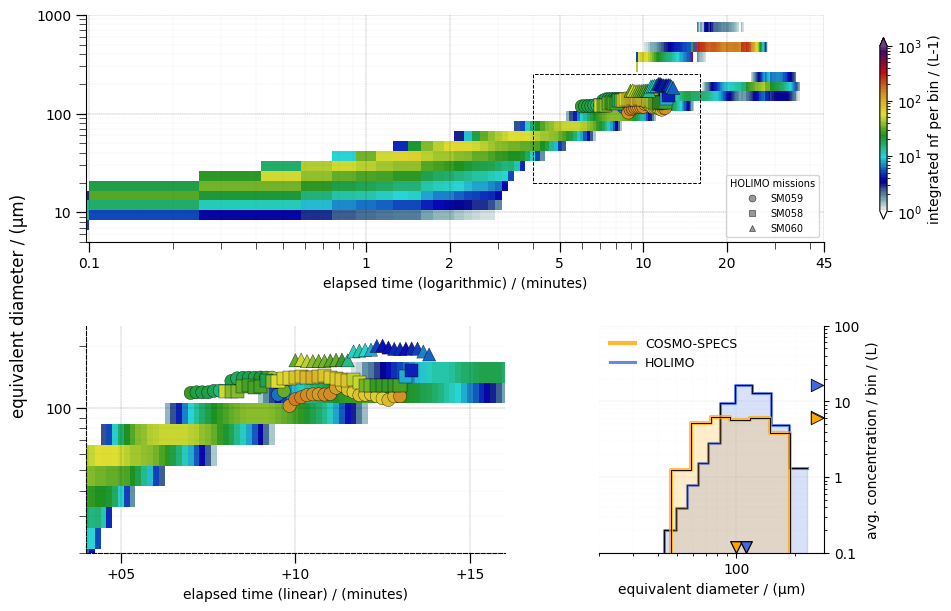

In [44]:

import matplotlib.pyplot as plt
from utilities import _assign_elapsed_time, _prepare_da
from matplotlib.lines import Line2D


# Updated FoO block: one model line over global HOLIMO elapsed window.
holimo_ice_var = "Ice_PSDnoNorm"
holimo_overlay_cfg = {
    "ds_hd10": ds_hd10,
    "obs_ids": obs_ids,
    "time_frames_plume": time_frames_plume,
    "growth_times_min": growth_times_min,
    "seeding_start_times": seeding_start_times,
    "var": holimo_ice_var,
    "threshold": 1e-10,
    "unit_factor": 1e3,
    "scatter_cmap": new_jet3_soft,
    "markers": ["o", "s", "^"],
    "sizes": [90, 90, 90],
    "alpha": 1.0,
    "edgecolor": "black",
    "linewidth": 0.25,
    "legend_loc": "lower right",
    "marker_size_scale": 1.0,
}

# Histogram settings for comparison panel.
xlim_npdatetime = [np.datetime64("2023-01-25T12:29:00"), np.datetime64("2023-01-25T13:14:00")]
xlims = {"symlog": [0, 45],   "elapsed": [4, 16]}
ylims = {"symlog": [5, 1000], "elapsed": [20, 250]}
zlims = {"symlog": [1, 1000], "elapsed": [1, 1000]}
zoom_window_config = [("symlog",  xlims["symlog"],  ylims["symlog"],  zlims["symlog"]), 
                      ("elapsed", xlims["elapsed"], ylims["elapsed"], zlims["elapsed"]),
                      ("hist",    (20.0, 280.0),    (0.1, 100.0),     (None, None))]
absolute_mode = True  # True: absolute time-mean concentration, False: FoO (%)

float_fmt = plt.FuncFormatter(lambda x, p: f'{x:.3f}'.rstrip('0').rstrip('.') if x < 1 else f'{x:.0f}')

# Main stacked pcolormesh figure.
fig_stack = plt.figure(figsize=(9.4, 6.0), constrained_layout=True)
gs = fig_stack.add_gridspec(2, 2, width_ratios=[0.65, 0.35], wspace=0.1, hspace=0.1)
ax_main = [fig_stack.add_subplot(gs[0, 0:2]), fig_stack.add_subplot(gs[1, 0])]
ax_hist = fig_stack.add_subplot(gs[1, 1])

cbar_kwargs={"shrink": 0.8, "aspect":25, "pad": 0.0, "extend":"both"}
pmesh_ref = None


def _diameter_centers_to_log_edges(diameter_centers: np.ndarray) -> np.ndarray:
    centers = np.asarray(diameter_centers, dtype=float)
    centers = np.sort(centers[np.isfinite(centers) & (centers > 0)])
    centers = np.unique(centers)
    if centers.size < 2:
        return np.array([], dtype=float)

    lcent = np.log(centers)
    ledges = np.empty(centers.size + 1, dtype=float)
    ledges[1:-1] = 0.5 * (lcent[:-1] + lcent[1:])
    ledges[0] = lcent[0] - 0.5 * (lcent[1] - lcent[0])
    ledges[-1] = lcent[-1] + 0.5 * (lcent[-1] - lcent[-2])
    return np.exp(ledges)


def _hist_profile_by_diameter(
    da: xr.DataArray,
    threshold: float,
    bin_edges: np.ndarray | None = None,
):
    if "time" not in da.dims or "diameter" not in da.dims:
        return np.array([]), np.array([])
    other_dims = [d for d in da.dims if d not in ("time", "diameter")]
    if other_dims:
        da = da.mean(dim=other_dims, skipna=True)

    diam = np.asarray(da["diameter"].values, dtype=float)
    tvals = np.asarray(da["time"].values)
    vals = np.asarray(da.values, dtype=float)
    if vals.ndim != 2 or vals.shape[1] != diam.size or vals.shape[0] != tvals.size:
        return np.array([]), np.array([])

    if bin_edges is None:
        bin_edges = _diameter_centers_to_log_edges(diam)
    else:
        bin_edges = np.asarray(bin_edges, dtype=float)

    if bin_edges.size < 2 or np.any(~np.isfinite(bin_edges)) or np.any(np.diff(bin_edges) <= 0):
        return np.array([]), np.array([])

    vals = np.where(np.isfinite(vals) & (vals > threshold), vals, 0.0)
    tmin = ((tvals - tvals[0]) / np.timedelta64(1, "m")).astype(float)
    prof = np.trapezoid(vals, x=tmin, axis=0)

    # Re-bin integrated profile on requested log-diameter boundaries.
    hist, _ = np.histogram(diam, bins=bin_edges, weights=prof)
    centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
    return centers, np.asarray(hist, dtype=float)


def _freq_occurrence_by_diameter(
    da: xr.DataArray,
    threshold: float,
    bin_edges: np.ndarray | None = None,
):
    centers, hist = _hist_profile_by_diameter(da=da, threshold=threshold, bin_edges=bin_edges)
    if centers.size == 0:
        return np.array([]), np.array([])
    total = float(np.nansum(hist))
    if not np.isfinite(total) or total <= 0:
        return centers, np.zeros_like(centers, dtype=float)
    return centers, np.asarray(100.0 * hist / total, dtype=float)

def _select_model_da_for_elapsed_window(da_model_elapsed: xr.DataArray, e_lo: float, e_hi: float) -> xr.DataArray:
    if not np.isfinite(e_lo) or not np.isfinite(e_hi):
        return da_model_elapsed.isel(time=slice(0, 0))
    if e_hi < e_lo:
        e_lo, e_hi = e_hi, e_lo
    return da_model_elapsed.where((da_model_elapsed.time_elapsed >= e_lo) & (da_model_elapsed.time_elapsed <= e_hi), drop=True)


def _select_holimo_da_for_elapsed_window(obs_elapsed_by_id: dict[str, xr.DataArray], obs_id: str, e_lo: float, e_hi: float) -> xr.DataArray:
    da = obs_elapsed_by_id.get(obs_id)
    if da is None:
        return xr.DataArray([], dims=("time",), coords={"time": []})
    if not np.isfinite(e_lo) or not np.isfinite(e_hi):
        return da.isel(time=slice(0, 0))
    if e_hi < e_lo:
        e_lo, e_hi = e_hi, e_lo
    return da.where((da.time_elapsed >= e_lo) & (da.time_elapsed <= e_hi), drop=True)


def _elapsed_duration_minutes(da: xr.DataArray) -> float:
    if "time" not in da.dims or da.sizes.get("time", 0) < 2:
        return 0.0
    tvals = np.asarray(da["time"].values)
    dt = float((tvals[-1] - tvals[0]) / np.timedelta64(1, "m"))
    return max(dt, 0.0)


for i, (fmt, xwin, ywin, zwin) in enumerate(zoom_window_config[:2]):
    _, axes_plotted, pmesh = plot_plume_path_sum(
        ensemble_datasets,
        kind="integrated",
        variable="nf",
        common_xlim_minutes=35,
        xlim=xlim_npdatetime,
        # ylim=ywin,#[5, 250],
        zlim=zwin,
        cmap=new_jet3_soft,
        log_norm=True,
        x_axis_fmt=fmt,
        add_missing_data=True,
        holimo_overlay=holimo_overlay_cfg,
        axes_override=[ax_main[i]],
        add_colorbar=False,
        add_shared_labels=False,
        annote_letters=False,
        return_pmesh=True,
        cbar_kwargs=cbar_kwargs,
        add_holimo_legend=(i == 0),
    )
    axes_plotted.flat[0].set_xlim(xwin)
    axes_plotted.flat[0].set_ylim(ywin)
    if pmesh_ref is None:
        pmesh_ref = pmesh

x1_lo, x1_hi = zoom_window_config[1][1]
y1_lo, y1_hi = zoom_window_config[1][2]
ax_main[0].add_patch(plt.Rectangle((x1_lo, y1_lo), x1_hi - x1_lo, y1_hi - y1_lo, 
                                   fill=False, edgecolor="black", linestyle="--", linewidth=.70, zorder=300))
ax_main[1].set_title("")

# Remove zero tick from symlog elapsed-time axis.
ax_main[0].set_xticks([t for t in ax_main[0].get_xticks() if not np.isclose(t, 0.0)])

for sp in ax_main[1].spines.values():
    sp.set_color("black")
    sp.set_linestyle("--")
    # sp.set_linewidth(2.0)

for ax in ax_main:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
ax_hist.spines["top"].set_visible(False)
ax_hist.spines["left"].set_visible(False)

unit = ensemble_datasets[next(iter(ensemble_datasets))]["integrated"]["nf"].attrs.get("units", "-")
cb = fig_stack.colorbar(pmesh_ref, ax=ax_main[0], **cbar_kwargs)
cb.set_label(rf"integrated nf per bin / ({unit})")


# ---- FoO: one model line over global HOLIMO elapsed window ----
run_label = next(k for k, v in ensemble_datasets.items() if isinstance(v.get("integrated"), xr.Dataset))
obs_threshold = holimo_overlay_cfg["threshold"]
obs_var = holimo_overlay_cfg["var"]
mission_ids = holimo_overlay_cfg["obs_ids"]
mission_frames = holimo_overlay_cfg["time_frames_plume"]
mission_seed_starts = holimo_overlay_cfg["seeding_start_times"]


# Convert datasets to elapsed time OUTSIDE plotting function.
idx_mod_ice_diam_start = 30 # start for sizes of 1µm for bin boundaries of histogram
model_seed_start = np.datetime64("2023-01-25T12:30:00")
da_model_elapsed = _prepare_da(ensemble_datasets[run_label]["integrated"], "nf", sum_cell=True)
da_model_elapsed = da_model_elapsed.sel(time=slice(*xlim_npdatetime))
da_model_elapsed = _assign_elapsed_time(da_model_elapsed, model_seed_start)

diam_mod = np.asarray(da_model_elapsed["diameter"].sel(diameter=slice(*ylims["elapsed"])).values, dtype=float)
diam_obs = np.asarray(ds_hd10[obs_var]["diameter"].sel(diameter=slice(*ylims["elapsed"])).values, dtype=float)

bin_edges_mod = _diameter_centers_to_log_edges(diam_mod)
bin_edges_obs = _diameter_centers_to_log_edges(diam_obs)

print(f"diam_mod ({diam_mod.size}): {diam_mod}")
print(f"diam_obs ({diam_obs.size}): {diam_obs}")
if bin_edges_mod.size >= 2:
    print(
        f"FoO binning check :: model nbins={bin_edges_mod.size - 1}, "
        f"range=[{bin_edges_mod[0]:.3f}, {bin_edges_mod[-1]:.3f}]"
    )
else:
    print("FoO binning check :: model has insufficient diameter points for log bins")
if bin_edges_obs.size >= 2:
    print(
        f"FoO binning check :: obs   nbins={bin_edges_obs.size - 1}, "
        f"range=[{bin_edges_obs[0]:.3f}, {bin_edges_obs[-1]:.3f}]"
    )
else:
    print("FoO binning check :: obs has insufficient diameter points for log bins")

obs_elapsed_by_id: dict[str, xr.DataArray] = {}
elapsed_windows = []
for i_mis, (obs_id, (t_lo, t_hi)) in enumerate(zip(mission_ids, mission_frames)):
    seed_t = np.datetime64(mission_seed_starts[i_mis])
    e_lo = float((np.datetime64(t_lo) - seed_t) / np.timedelta64(1, "m"))
    e_hi = float((np.datetime64(t_hi) - seed_t) / np.timedelta64(1, "m"))
    elapsed_windows.append((min(e_lo, e_hi), max(e_lo, e_hi)))

    if obs_var in ds_hd10:
        da_obs_i = ds_hd10[obs_var].sel(time=slice(t_lo, t_hi)) * holimo_overlay_cfg["unit_factor"]
        if da_obs_i.sizes.get("time", 0) > 0:
            obs_elapsed_by_id[obs_id] = _assign_elapsed_time(da_obs_i, seed_t)

# Global HOLIMO elapsed window envelope for ONE model line.
e_lo_global = min(w[0] for w in elapsed_windows)
e_hi_global = max(w[1] for w in elapsed_windows)
da_model = _select_model_da_for_elapsed_window(da_model_elapsed, e_lo_global, e_hi_global)
if absolute_mode:
    d_model, hist_model = _hist_profile_by_diameter(da_model, bin_edges=bin_edges_mod, threshold=0.0)
    dur_model = _elapsed_duration_minutes(da_model)
    f_model = hist_model / dur_model if dur_model > 0 else np.array([])
else:
    d_model, f_model = _freq_occurrence_by_diameter(da_model, bin_edges=bin_edges_mod, threshold=0.0)

if d_model.size and np.isfinite(f_model).any():
    ax_hist.fill_between(
        d_model,
        f_model,
        step="pre",
        color="orange",
        alpha=0.20,
        zorder=13,
    )
    ax_hist.step(
        d_model,
        f_model,
        color="orange",
        lw=3.0,
        linestyle="-",
        label="COSMO-SPECS",
        alpha=0.7,
        zorder=14,
    )
    ax_hist.step(
        d_model,
        f_model,
        color="black",
        lw=0.7,
        linestyle="-",
        alpha=0.95,
        zorder=15,
    )

# Combined HOLIMO histogram across all seeding missions.
hist_obs_sum = None
d_obs_ref = np.array([])
dur_obs_sum = 0.0
for i_mis, (obs_id, (t_lo, t_hi)) in enumerate(zip(mission_ids, mission_frames)):
    seed_t = np.datetime64(mission_seed_starts[i_mis])
    e_lo = float((np.datetime64(t_lo) - seed_t) / np.timedelta64(1, "m"))
    e_hi = float((np.datetime64(t_hi) - seed_t) / np.timedelta64(1, "m"))

    da_obs = _select_holimo_da_for_elapsed_window(obs_elapsed_by_id, obs_id, e_lo, e_hi)
    d_obs_i, hist_obs_i = _hist_profile_by_diameter(da_obs, bin_edges=bin_edges_obs, threshold=obs_threshold)
    if d_obs_i.size and not np.isfinite(hist_obs_i).any():
        d_obs_i, hist_obs_i = _hist_profile_by_diameter(da_obs, bin_edges=bin_edges_obs, threshold=0.0)

    if d_obs_i.size and np.isfinite(hist_obs_i).any():
        if hist_obs_sum is None:
            d_obs_ref = d_obs_i
            hist_obs_sum = np.array(hist_obs_i, dtype=float)
        elif hist_obs_sum.shape == hist_obs_i.shape:
            hist_obs_sum += np.asarray(hist_obs_i, dtype=float)
        dur_obs_sum += _elapsed_duration_minutes(da_obs)

if hist_obs_sum is not None and np.isfinite(hist_obs_sum).any():
    if absolute_mode:
        f_obs_all = hist_obs_sum / dur_obs_sum if dur_obs_sum > 0 else np.array([])
    else:
        total_obs = float(np.nansum(hist_obs_sum))
        f_obs_all = np.asarray(100.0 * hist_obs_sum / total_obs, dtype=float) if np.isfinite(total_obs) and total_obs > 0 else np.array([])

    if f_obs_all.size and np.isfinite(f_obs_all).any():
        ax_hist.fill_between(
            d_obs_ref,
            f_obs_all,
            step="pre",
            color="royalblue",
            alpha=0.2,
            zorder=5,
            label="_nolegend_",
        )
        ax_hist.step(
            d_obs_ref,
            f_obs_all,
            color="royalblue",
            lw=2.2,
            linestyle="-",
            alpha=0.8,
            zorder=6,
            label="HOLIMO",
        )
        ax_hist.step(
            d_obs_ref,
            f_obs_all,
            color="black",
            lw=0.7,
            linestyle="-",
            alpha=0.95,
            zorder=7,
        )

ax_hist.set_xscale("log")
ax_hist.set_yscale("log")
ax_hist.set_ylabel("avg. concentration / bin / (L)")
ax_hist.set_xlabel("equivalent diameter / (µm)")
ax_hist.set_xlim(zoom_window_config[2][1])
ax_hist.set_ylim(zoom_window_config[2][2])
ax_hist.grid(True, which="major", linestyle="--", linewidth=0.25, alpha=0.6)
ax_hist.grid(True, which="minor", linestyle=":", linewidth=0.15, alpha=0.35)
ax_hist.yaxis.tick_right()
ax_hist.yaxis.set_label_position("right")
ax_hist.xaxis.set_major_formatter(float_fmt)
ax_hist.yaxis.set_major_formatter(float_fmt)    


def _local_max_indices(f, n_max=2):
    """Indices of up to n_max local maxima, sorted by value descending."""
    f = np.asarray(f, dtype=float)
    n = len(f)
    if n < 3:
        return (np.argmax(f),) if n > 0 and np.isfinite(f).any() else ()
    peak_idx = []
    for i in range(1, n - 1):
        if np.isfinite(f[i]) and f[i] >= f[i - 1] and f[i] >= f[i + 1]:
            peak_idx.append(i)
    if not peak_idx:
        peak_idx = [int(np.nanargmax(f))]
    peak_idx = sorted(peak_idx, key=lambda i: f[i], reverse=True)[:n_max]
    return tuple(peak_idx)

def _median_diameters_for_modes(d, f, peak_indices):
    """Given diameters d, profile f, and peak indices (1 or 2), return list of median diameters per mode."""
    d, f = np.asarray(d, dtype=float), np.asarray(f, dtype=float)
    n = len(d)
    if not peak_indices or n < 2:
        return []
    if len(peak_indices) == 1:
        cdf = np.nancumsum(f)
        tot = cdf[-1]
        if not np.isfinite(tot) or tot <= 0:
            return []
        return [float(np.interp(0.5, cdf / tot, d))]
    i1, i2 = sorted(peak_indices)[0], sorted(peak_indices)[1]
    i_valley = i1 + int(np.nanargmin(f[i1:i2 + 1]))
    meds = []
    for (start, end) in [(0, i_valley + 1), (i_valley + 1, n)]:
        if end <= start:
            continue
        fi, di = f[start:end], d[start:end]
        cdf = np.nancumsum(fi)
        tot = cdf[-1]
        if not np.isfinite(tot) or tot <= 0:
            continue
        meds.append(float(np.interp(0.5, cdf / tot, di)))
    return meds

x_max_lim = zoom_window_config[2][1][1]
if d_model.size and np.isfinite(f_model).any():
    for imax in _local_max_indices(f_model, n_max=2):
        y_peak = float(f_model[imax])
        ax_hist.scatter(x_max_lim*0.92, y_peak, marker=">", s=80, color="orange", edgecolors="black", linewidths=0.6, zorder=100, clip_on=True)
if "d_obs_ref" in locals() and d_obs_ref.size and np.isfinite(f_obs_all).any():
    for imax in _local_max_indices(f_obs_all, n_max=1):
        y_peak = float(f_obs_all[imax])
        ax_hist.scatter(x_max_lim*0.92, y_peak, marker=">", s=80, color="royalblue", edgecolors="black", linewidths=0.6, zorder=100, clip_on=True)

# Histogram legend (names only; maxima marked with triangles).
legend_handles, legend_labels = [], []
if 'f_model' in locals() and hasattr(f_model, 'size') and f_model.size and np.isfinite(f_model).any():
    legend_handles.append(Line2D([], [], color="orange", lw=3.0, linestyle="-", alpha=0.8))
    legend_labels.append("COSMO-SPECS")
if 'f_obs_all' in locals() and f_obs_all.size and np.isfinite(f_obs_all).any():
    legend_handles.append(Line2D([], [], color="royalblue", lw=2.2, linestyle="-", alpha=0.8))
    legend_labels.append("HOLIMO")
if legend_handles:
    ax_hist.legend(legend_handles, legend_labels, loc="upper left", frameon=False, fontsize=9)
ax_main[0].set_title("")
ax_main[0].set_xlabel("elapsed time (logarithmic) / (minutes)")
ax_main[1].set_xlabel("elapsed time (linear) / (minutes)")
ax_main[1].yaxis.set_major_formatter(float_fmt)

# Median diameter markers at bottom of hist (must be after set_yscale/set_ylim so y is in log coords). If bimodal, plot both. Two y-levels so model and obs "v" don't overlap.
y_axis_bottom = 1.2 * ax_hist.get_ylim()[0]
y_obs_v = y_axis_bottom * 1.  # obs "v" on a higher rail so both visible when medians align
if d_model.size and np.isfinite(f_model).any():
    peak_idx_mod = _local_max_indices(f_model, n_max=1)
    for med_d_mod in _median_diameters_for_modes(d_model, f_model, peak_idx_mod):
        ax_hist.scatter(med_d_mod, y_axis_bottom, marker="v", s=70, color="orange", edgecolors="black", linewidths=0.9, zorder=100, clip_on=True)
    
if "d_obs_ref" in locals() and d_obs_ref.size and np.isfinite(f_obs_all).any():
    peak_idx_obs = _local_max_indices(f_obs_all, n_max=1)
    for med_d_obs in _median_diameters_for_modes(d_obs_ref, f_obs_all, peak_idx_obs):
        ax_hist.scatter(med_d_obs, y_obs_v, marker="v", s=70, color="royalblue", edgecolors="black", linewidths=0.9, zorder=100, clip_on=True)
        
fig_stack.supylabel("equivalent diameter / (µm)")
fig_stack.savefig("output/figure12_ensemble_mean_plume_path_foo.png", dpi=500, bbox_inches="tight")
